### Supp - Extra-correctness, parse event by event, by time

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import starbars
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_figures.figure3d import find_theta_dynamics_animals
from spyglass.shijiegu.changeOfMind_figures.dynamic_home_arm import (return_remote_time,
    return_meta_data, GLM_max_proportion, model2numbers, violin_plot)
from spyglass.shijiegu.changeOfMind_figures.dynamic_home_arm import (
    GLM_correctness_time)

[2026-05-25 17:34:09,011][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) d

In [3]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

# encoding_set = 'all_maze'
# classifier_param_name = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']
seq_animals[animal] = 'rev2'

parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
hpd = False

local_parameter = f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"
remote_parameter = f"dur_{minimum_duration_remote}_sum_{min_posterior}"

In [90]:
success = {}
for animal in ["julio"]: 
    if animal == "julio":
        theta_type = "corpus_callosum"
    else:
        theta_type = "mua"
    
    (Ns_remote, remote_time_spent, trial_infos,
     rewards, Ns_long, long_time_spent) = return_remote_time(animal, list_of_days_animals[animal], sd = sd, theta_type = theta_type)
    

    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/supp_home_arm_remote_count_{animal}_{sd}'
    data = {
            "remote_time_spent":remote_time_spent,
            "Ns_remote": Ns_remote,
            "trial_infos": remote_trial_infos,
            "long_time_spent":long_time_spent,
            "Ns_long": Ns_long,
            "rewards": rewards,
    }
    file_path = output_folder + '.pkl'
    with open(file_path, 'wb') as file:
        print("data saved to " + file_path)
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    success[animal] = 1

[2026-05-18 15:38:21,116][WARNING]: Skipped checksum for file with hash: 9fd9ff10-8246-d832-8f13-c1f2b235e1b0, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_16ZI5PUM48.nwb


julio20230731_.nwb


[2026-05-18 15:38:22,009][WARNING]: Skipped checksum for file with hash: 0c34f0a0-b359-2ad7-ce9f-b840c9191951, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_UX6B20HBXI.nwb
[15:38:22][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-05-18 15:38:24,005][WARNING]: Skipped checksum for file with hash: 325fe2f4-8654-aef5-a65a-689a64e66b7c, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_36HZ4X4TXC.nwb
[2026-05-18 15:38:24,011][WARNING]: Skipped checksum for file with hash: 325fe2f4-8654-aef5-a65a-689a64e66b7c, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_36HZ4X4TXC.nwb
[2026-05-18 15:38:24,231][WARNING]: Skipped checksum for file with hash: b81d2645-358d-738d-5184-3554

parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind
parsing multiple change of mind


[2026-05-18 15:38:25,223][WARNING]: Skipped checksum for file with hash: 88642bc6-f0b0-98de-90aa-796474351f42, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_MXZMD96E2E.nwb
[15:38:25][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-05-18 15:38:27,368][WARNING]: Skipped checksum for file with hash: a2c5fe0e-2e5d-a414-e24c-7a484d9e19db, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_N26FWB8QQR.nwb
[2026-05-18 15:38:27,376][WARNING]: Skipped checksum for file with hash: a2c5fe0e-2e5d-a414-e24c-7a484d9e19db, and path: /stelmo/nwb/analysis/julio20230731/julio20230731_N26FWB8QQR.nwb
[2026-05-18 15:38:27,659][WARNING]: Skipped checksum for file with hash: 0789e633-8a6e-ebd7-ac1f-faeb

...

No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_segment_run_time_2_state'}


[2026-05-18 15:40:55,192][WARNING]: Skipped checksum for file with hash: 122175ee-1d82-4087-88e2-6edeec83f6ef, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_78X086LT4V.nwb


No triggered decode found for  {'nwb_file_name': 'julio20230811_.nwb', 'epoch': 6, 'proportion': 0.1, 'parameter': 'params_both_max_segment_run_time_2_state'}


[2026-05-18 15:40:55,974][WARNING]: Skipped checksum for file with hash: 6e12fbeb-7937-20c2-a9a5-f17e1fba6de6, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_EHUTGPRCXX.nwb
[15:40:56][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-05-18 15:40:57,892][WARNING]: Skipped checksum for file with hash: 36ccae0e-a5fe-aa5b-4742-1ea050ad9f60, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_ZS628HNU00.nwb
[2026-05-18 15:40:57,897][WARNING]: Skipped checksum for file with hash: 36ccae0e-a5fe-aa5b-4742-1ea050ad9f60, and path: /stelmo/nwb/analysis/julio20230811/julio20230811_ZS628HNU00.nwb
[2026-05-18 15:40:58,039][WARNING]: Skipped checksum for file with hash: ba93a12b-a54e-0341-1cff-5376

parsing multiple change of mind
parsing multiple change of mind
data saved to /stelmo/shijie/change_of_mind_analysis/figure3/supp_home_arm_remote_count_julio_6.pkl


In [91]:
success

{'julio': 1}

### load data backin

In [4]:
Ns_remote = {}
remote_time_spent = {}
rewards = {}

Ns_long = {}
long_time_spent = {}

sd=6
for animal in ["molly", "eliot", "julio", "klein", "lewis"]:
    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/supp_home_arm_remote_count_{animal}_{sd}'
    file_path = output_folder + '.pkl'

    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    remote_time_spent[animal] = data["remote_time_spent"]
    long_time_spent[animal] = data["long_time_spent"]
    Ns_remote[animal] = data["Ns_remote"]
    Ns_long[animal] = data["Ns_long"]
    rewards[animal] = data["rewards"]


### 1. Simple conditioning plot

In [7]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

def sd_err(arr):
    return np.std(arr)/np.sqrt(len(arr))

def plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],color = color_by_rat[animal], alpha=0.8)
    if draw_text:
        ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)
        
    res = ranksums(data1, data2)
    p_value = res.pvalue
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value

def draw_annotation(ijps,ax,height = 0.9):
    for ijp in ijps:
        x1, x2, p = ijp
        if p <= 0.001:
            label = "***"
        elif p <= 0.01:
            label = "**"
        elif p <= 0.05:
            label = "*"
        ax.text(np.mean([x1,x2]), height, label)

def add_num(num, height, ax, x1):
    ax.text(x1, height, str(int(num)), color = "k")

pvalue 0.5074897001577392
pvalue 0.5132436113366214
pvalue 0.6334244877372394
pvalue 0.592561984660436
pvalue 0.47507315008471407
pvalue 0.43061660032306426
pvalue 0.6870140294448688
pvalue 0.7225765486432132
pvalue 0.5240891522658366
pvalue 0.5152152738855984
pvalue 0.36003881039252794
pvalue 0.39158025777094485
pvalue 0.06401693214221564
pvalue 0.07013631197633705
pvalue 0.6994378859948254
pvalue 0.6994378859948254
pvalue 0.10789399784437612
pvalue 0.11938187797602655
pvalue 0.9626862344594147
pvalue 0.9291344533525879
pvalue 0.5263066934126754
pvalue 0.5062499708129311
pvalue 0.8595544374198397
pvalue 0.6743978144680557
pvalue 0.14796444252332397
pvalue 0.16086486347352236
pvalue 0.015834022844257795
pvalue 0.015274464970061427
pvalue 0.00820719632198534
pvalue 0.007335214997289837
5.005 0.03
5.005 0.03
5.005 0.03
5.005 0.03


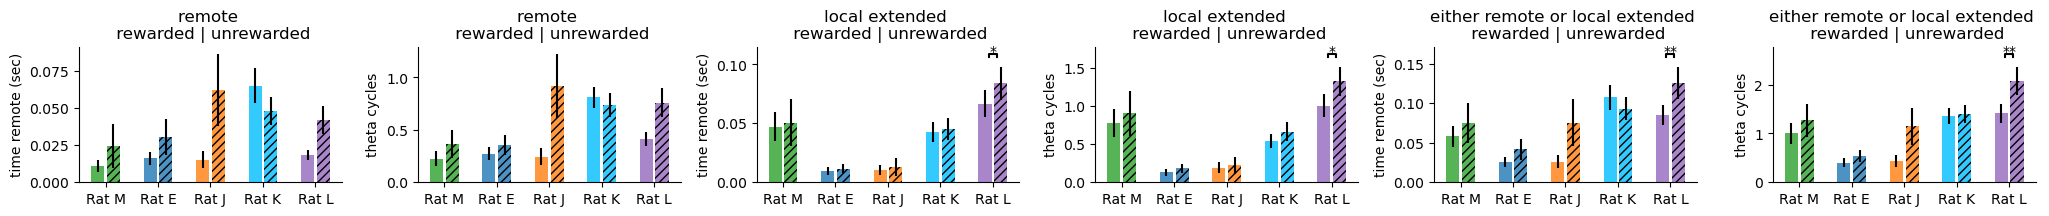

In [8]:
num_of_panels = 6
draw_text = False
fig, axes = plt.subplots(1, num_of_panels, figsize=(3.5 * num_of_panels, 2.8))#sharey = True)

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]#["molly","lewis","julio","klein"]

annotations = {i:[] for i in range(num_of_panels)}

for animal in animals:

    (reward,
     time_r, N_r, time_l, N_l) = (
        np.array(rewards[animal]),
        np.array(remote_time_spent[animal]),
         np.array(Ns_remote[animal]),
         np.array(long_time_spent[animal]),
         np.array(Ns_long[animal]))

    # time_r > 0
    ind1 = np.logical_and(reward > 0, time_r >= 0)
    ind2 = np.logical_and(reward == 0, time_r >= 0)
    
    time_spent_reward = time_r[ind1]
    time_spend_nonreward = time_r[ind2]
    N_reward = N_r[ind1]
    N_nonreward = N_r[ind2]

    # axis 1: nontheta vs theta
    ax = axes[0]
    data2, data1 = time_spent_reward, time_spend_nonreward
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
    print("pvalue",pvalue)
    if pvalue <= 0.05:
        annotations[0].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    #add_num(len(data1), 0.2, ax, animal_ind)
    #add_num(len(data2), 0.2, ax, animal_ind + 0.4)

    # axis 1: nontheta vs theta
    ax = axes[1]
    data2, data1 = N_reward, N_nonreward
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
    print("pvalue",pvalue)
    if pvalue <= 0.05:
        annotations[1].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    #add_num(len(data1), 3, ax, animal_ind)
    #add_num(len(data2), 3, ax, animal_ind + 0.4)

    # time_l > 0
    ind1 = np.logical_and(reward > 0, time_l >= 0)
    ind2 = np.logical_and(reward == 0, time_l >= 0)
    
    time_spent_reward = time_l[ind1]
    time_spend_nonreward = time_l[ind2]
    N_reward = N_l[ind1]
    N_nonreward = N_l[ind2]

    # axis 1: nontheta vs theta
    ax = axes[2]
    data2, data1 = time_spent_reward, time_spend_nonreward
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
    print("pvalue",pvalue)
    if pvalue <= 0.05:
        annotations[2].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    #add_num(len(data1), 0.2, ax, animal_ind)
    #add_num(len(data2), 0.2, ax, animal_ind + 0.4)

    # axis 1: nontheta vs theta
    ax = axes[3]
    data2, data1 = N_reward, N_nonreward
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
    print("pvalue",pvalue)
    if pvalue <= 0.05:
        annotations[3].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    #add_num(len(data1), 3, ax, animal_ind)
    #add_num(len(data2), 3, ax, animal_ind + 0.4)

    # time_l > 0
    ind1 = np.logical_and(reward > 0, np.logical_or(time_l >= 0, time_r >= 0))
    ind2 = np.logical_and(reward == 0, np.logical_or(time_l >= 0, time_r >= 0))
    
    time_spent_reward = time_l[ind1] + time_r[ind1]
    time_spend_nonreward = time_l[ind2] + time_r[ind2]
    N_reward = N_l[ind1] + N_r[ind1]
    N_nonreward = N_l[ind2] + N_r[ind2]

    # axis 1: nontheta vs theta
    ax = axes[4]
    data2, data1 = time_spent_reward, time_spend_nonreward
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
    print("pvalue",pvalue)
    if pvalue <= 0.05:
        annotations[4].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    #add_num(len(data1), 0.3, ax, animal_ind)
    #add_num(len(data2), 0.3, ax, animal_ind + 0.4)

    # axis 1: nontheta vs theta
    ax = axes[5]
    data2, data1 = N_reward, N_nonreward
    _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal, draw_text = draw_text)
    print("pvalue",pvalue)
    if pvalue <= 0.05:
        annotations[5].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    if draw_text:
        add_num(len(data1), 2, ax, animal_ind)
        add_num(len(data2), 2, ax, animal_ind + 0.4)

    animal_ind += 1


for j in range(6):
    ax = axes[j]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
        
    ax.set_xticks(np.arange(len(animals)) + .15);
    ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
    if j % 2 == 0:
        ax.set_ylabel("time remote (sec)")
    else:
        ax.set_ylabel("theta cycles")

    if j == 0 or j == 1:
        title = "remote \n rewarded | unrewarded"
    elif j == 2 or j == 3:
        title = "local extended \n rewarded | unrewarded"
    else:
        title = "either remote or local extended \n rewarded | unrewarded"
    if j % 2 == 0:
        starbars.draw_annotation(annotations[j], ax)
    else:
        starbars.draw_annotation(annotations[j], ax)
        
    ax.set_title(title)

plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/supp_extra_correctness_{draw_text}.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

In [7]:
Ns = {}
time_spent = {}
for animal in remote_time_spent.keys():
    Ns[animal] = np.array(Ns_long[animal]) + np.array(Ns_remote[animal])
    time_spent[animal] = np.array(remote_time_spent[animal]) + np.array(long_time_spent[animal])

model, logit_result = GLM_correctness_time(Ns, "num of theta cycle",
                                      rewards)
print(logit_result.summary())

#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logit_result)
coef_est = np.exp(coef_est)
CI = np.exp(CI)

print(coef_est)
print(CI)

# model, logit_result2 = GLM_correctness_time(time_spent, "time spent",
#                                       rewards)
#print(logit_result2.summary())

Optimization terminated successfully.
         Current function value: 0.654204
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1345
Model:                          Logit   Df Residuals:                     1339
Method:                           MLE   Df Model:                            5
Date:                Fri, 22 May 2026   Pseudo R-squ.:                0.005007
Time:                        17:33:43   Log-Likelihood:                -879.90
converged:                       True   LL-Null:                       -884.33
Covariance Type:            nonrobust   LLR p-value:                    0.1150
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.5227   3.02e+06  -1.73e-07      1.000   -5.93e+06    5.93e+06
Rat M

0.11000000000000001 0.03


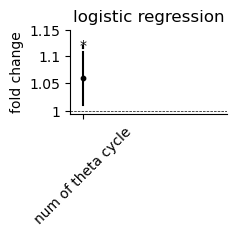

In [13]:
#### axis 1
fig, axes = plt.subplots(1,1,figsize=(3, 3))

coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logit_result)
coef_est = np.exp(coef_est)
CI = np.exp(CI)

for (ind,coef_name) in enumerate(coef_names):
    axes.scatter(coef_name, coef_est[ind], color = "k", s = 10)
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes, color = 'k')

axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
axes.set_title("logistic regression")
axes.set_ylabel("fold change")
axes.axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
#axes.set_ylim([0.5,3])
axes.set_xlim([-0.3,3.3])

axes.set_yscale('log') 
axes.set_yticks([1,1.05,1.1,1.15])
axes.set_yticklabels([1,1.05,1.1,1.15])
axes.set_yticks([], minor=True)

axes.spines[['right', 'top']].set_visible(False)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/supp_extra_correctness_GLM.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")
